In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 104.9 MB/s eta 0:00:00


Loading ONNX model...
✓ ONNX model loaded successfully!

ONNX INFERENCE STARTED

Processing CMP: 30 images
  ✗ CMP_022.png → LER (88.16%)
  ✗ CMP_006.png → GOOD (64.34%)
  ✗ CMP_003.png → OPENS (87.42%)
  ✗ CMP_004.png → OPENS (98.30%)
  ✗ CMP_027.png → OPENS (99.90%)
  ✗ CMP_005.png → VIAS (60.40%)
  ✗ CMP_025.png → BRIDGES (97.97%)
  ✗ CMP_007.png → VIAS (95.19%)
  ✗ CMP_023.png → GOOD (89.97%)
  ✗ CMP_020.png → CRACK (99.28%)
  Accuracy: 20/30 (66.67%)

Processing LER: 30 images
  ✗ LER_017.png → CMP (81.90%)
  ✗ LER_019.png → CMP (72.15%)
  ✗ LER_026.png → CMP (99.31%)
  ✗ LER_021.png → OPENS (60.04%)
  ✗ LER_015.png → OPENS (94.23%)
  ✗ LER_018.png → OPENS (95.73%)
  ✗ LER_008.png → GOOD (59.62%)
  ✗ LER_020.png → OPENS (79.00%)
  ✗ LER_023.png → OPENS (87.64%)
  ✗ LER_014.png → OPENS (61.35%)
  ✗ LER_001.png → GOOD (90.28%)
  Accuracy: 19/30 (63.33%)

Processing BRIDGES: 32 images
  ✗ BRG_006.png → GOOD (99.30%)
  ✗ BRG_005.png → OPENS (74.66%)
  ✗ BRG_010.png → VIAS (98.73%)
  ✗

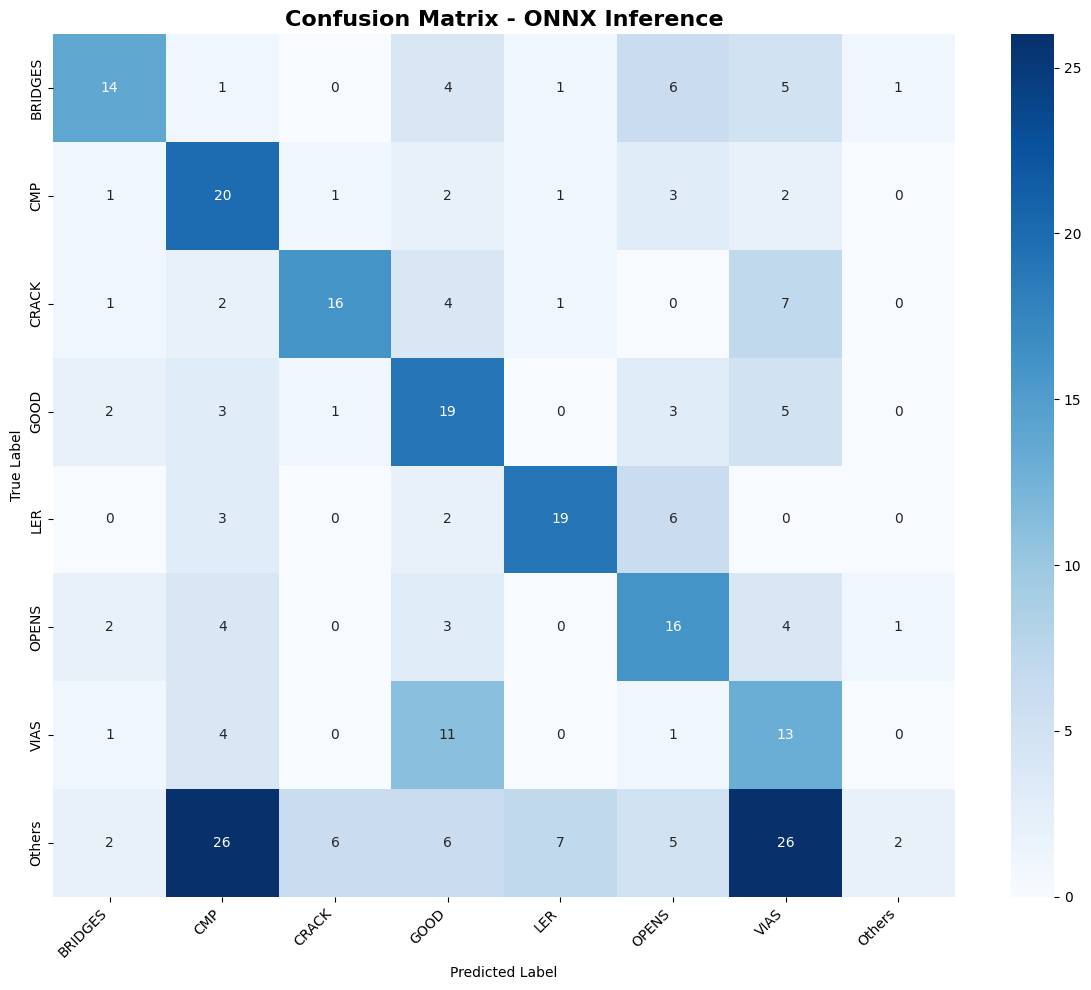

✓ Confusion matrix saved as 'confusion_matrix_onnx.png'

✅ ONNX INFERENCE COMPLETED!


In [14]:
# ============================================================
# COMPLETE ONNX INFERENCE SCRIPT WITH "OTHERS" SUPPORT
# ============================================================

import onnxruntime as ort
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

MODEL_PATH = "/content/mobilenetv3_int16.onnx"
INFERENCE_DIR = "/content/drive/MyDrive/hackathon_test_dataset"

IMG_SIZE = (224, 224)
CONFIDENCE_THRESHOLD = 0.5


class_names = ['BRIDGES', 'CMP', 'CRACK', 'GOOD', 'LER', 'OPENS', 'VIAS']

extended_class_names = class_names + ["Others"]


# ============================================================
# LOAD ONNX MODEL
# ============================================================

print("Loading ONNX model...")
session = ort.InferenceSession(MODEL_PATH)
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
print("✓ ONNX model loaded successfully!")

# ============================================================
# PREPROCESSING (Same as training)
# ============================================================

preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

def load_and_preprocess_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img_array = np.array(img).astype(np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array


def predict_single_image(image_path):
    img_array = load_and_preprocess_image(image_path)

    outputs = session.run([output_name], {input_name: img_array})
    predictions = outputs[0][0]

    predicted_idx = np.argmax(predictions)
    confidence = predictions[predicted_idx]

    if confidence < CONFIDENCE_THRESHOLD:
        return "Others", confidence
    else:
        return class_names[predicted_idx], confidence


# ============================================================
# INFERENCE ON ORGANIZED FOLDER
# ============================================================

def inference_organized_folder(base_dir):

    all_predictions = []
    all_true_labels = []
    all_confidences = []
    results_per_class = {}

    print("\n" + "="*60)
    print("ONNX INFERENCE STARTED")
    print("="*60)

    for class_folder in os.listdir(base_dir):

        class_path = os.path.join(base_dir, class_folder)

        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        print(f"\nProcessing {class_folder}: {len(images)} images")

        correct = 0

        if class_folder in class_names:
            true_idx = class_names.index(class_folder)
        else:
            true_idx = len(class_names)

        for img_name in images:

            img_path = os.path.join(class_path, img_name)

            try:
                predicted_class, confidence = predict_single_image(img_path)

                if predicted_class == "Others":
                    pred_idx = len(class_names)
                else:
                    pred_idx = class_names.index(predicted_class)

                all_predictions.append(pred_idx)
                all_true_labels.append(true_idx)
                all_confidences.append(confidence)

                if pred_idx == true_idx:
                    correct += 1
                else:
                    print(f"  ✗ {img_name} → {predicted_class} ({confidence:.2%})")

            except Exception as e:
                print(f"  ⚠ Error: {img_name} → {str(e)}")

        accuracy = correct / len(images) if len(images) > 0 else 0
        results_per_class[class_folder] = accuracy

        print(f"  Accuracy: {correct}/{len(images)} ({accuracy:.2%})")

    # ============================================================
    # OVERALL RESULTS
    # ============================================================

    print("\n" + "="*60)
    print("OVERALL RESULTS")
    print("="*60)

    overall_accuracy = np.mean(np.array(all_predictions) ==
                               np.array(all_true_labels))

    avg_confidence = np.mean(all_confidences)

    print(f"Overall Accuracy: {overall_accuracy:.2%}")
    print(f"Average Confidence: {avg_confidence:.2%}")
    print(f"Total Images: {len(all_predictions)}")

    print("\nPer-Class Accuracy:")
    for cls, acc in results_per_class.items():
        print(f"  {cls:15s}: {acc:.2%}")

    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================

    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)

    print(classification_report(
        all_true_labels,
        all_predictions,
        target_names=extended_class_names,
        zero_division=0
    ))

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(all_true_labels, all_predictions)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=extended_class_names,
                yticklabels=extended_class_names)

    plt.title("Confusion Matrix - ONNX Inference",
              fontsize=16, fontweight='bold')
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("confusion_matrix_onnx.png", dpi=300)
    plt.show()

    print("✓ Confusion matrix saved as 'confusion_matrix_onnx.png'")

    return all_predictions, all_true_labels, all_confidences


# ============================================================
# RUN
# ============================================================

predictions, true_labels, confidences = inference_organized_folder(INFERENCE_DIR)

print("\n" + "="*60)
print(" ONNX INFERENCE COMPLETED!")
print("="*60)
